### 1. Import Libraries 

In [1]:
# Load Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset & Overview

In [2]:
# Convert relative path safely
raw_path = ("../data/raw/train.csv")

# Load the dataset
df = pd.read_csv(raw_path)

# Display the first few rows
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 3. Exploratary Data Analysis (EDA)

In [3]:
# Shape of the dataset
df.shape

(1460, 81)

In [9]:
# Show summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
# Display a concise summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

- Since the dataset contains 81 columns, the default ```df.info()``` output is difficult to interpret. A better approach is to split the columns into numerical and categorical groups.

In [7]:
# Separate feature types
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

print(f'Numerical columns:{len(num_cols)}\n{num_cols}')
print(f'\nCategorical columns:{len(cat_cols)}\n{cat_cols}')


Numerical columns:38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

Categorical columns:43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtF

In [8]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


##### **Missing Values Analysis**

In [10]:
# Count missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Columns with missing values: {len(missing)}')
missing.head(15)

Columns with missing values: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
dtype: int64

- There were total 19 columns that contains missing values. Major value are missing in ```PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu, LotFrontage```.
- All Columns related to Garage have same missing values. This means they are independent on each other. Suppose if some property does not have Garage which means all the values related to columns will be missing. 

In [11]:
# Numerical columns missing values
print(df[num_cols].isnull().sum()[df[num_cols].isnull().sum() > 0])

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


``Note: We have fewer numeric columns, meaning most columns are categorical with missing values.``
- The LotFrontage column has the highest number of missing values (LotFrontage: linear feet of street connected to the property).
- The GarageYrBlt column also has missing values, which depend on the presence of a garage.
- We need to analyze this column further before handling missing values.

In [28]:
# Categorical columns with missing values
print(df[cat_cols].isnull().sum()[df[cat_cols].isnull().sum() > 0])

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


**Observation**

- Several categorical columns contain a large number of missing values.
- Columns such as ``PoolQC, MiscFeature, Alley, and Fence``have very high missing counts, indicating that these features are not available for most properties.
- Basement-related columns ``BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2`` and garage-related columns ``GarageType, GarageFinish, GarageQual, GarageCond`` also have missing values, likely because some houses lack a basement or garage.

**Next Steps**

* Drop columns with excessive missing values ``PoolQC, MiscFeature, Alley, and Fence`` as they provide limited information.
* For basement and garage columns, fill missing values with `"None"` to indicate absence.
* For columns with very few missing values (e.g.``Electrical``), fill them with the mode (most frequent value).

##### **Numerical Columns Univariate Analysis**

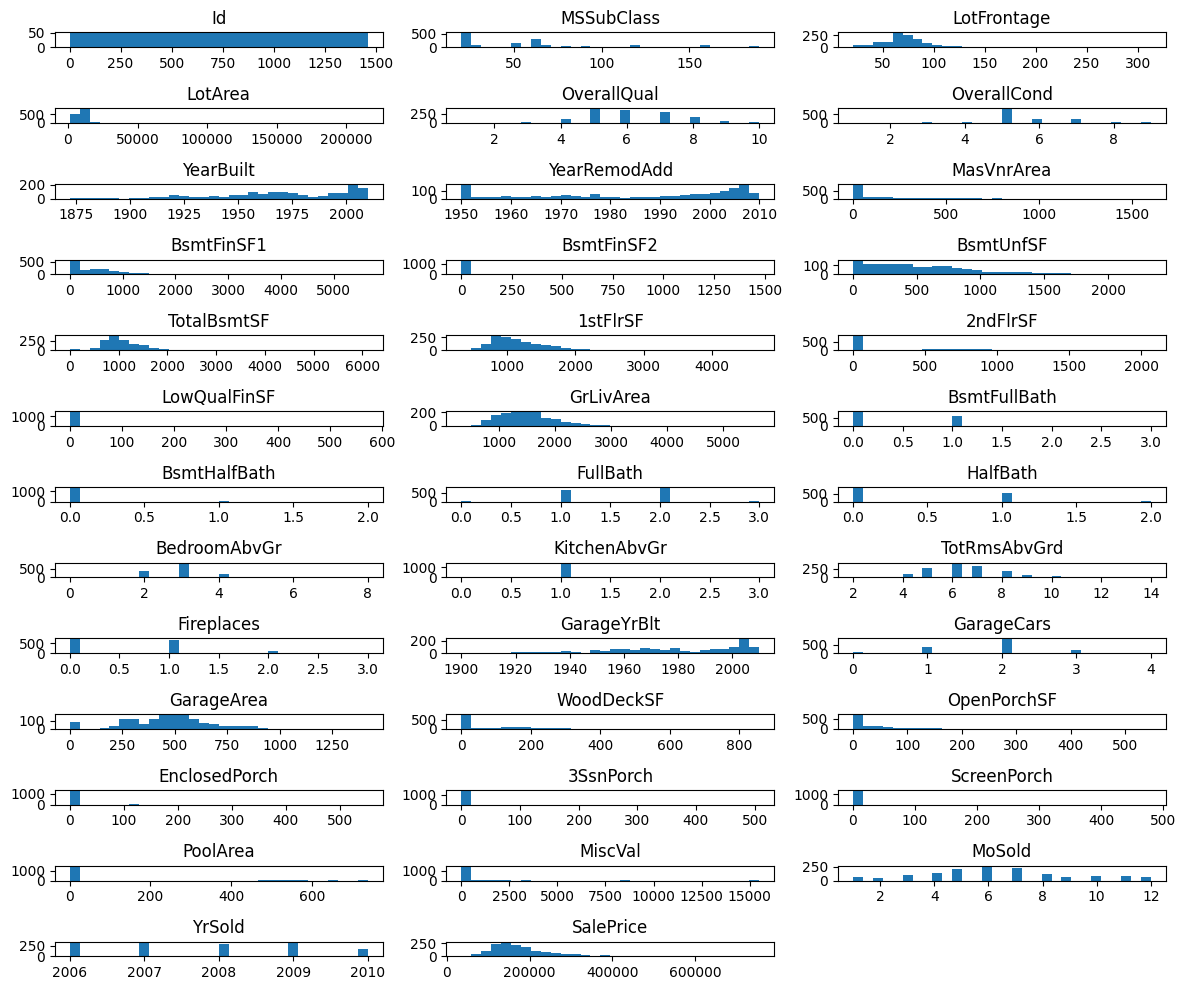

In [26]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

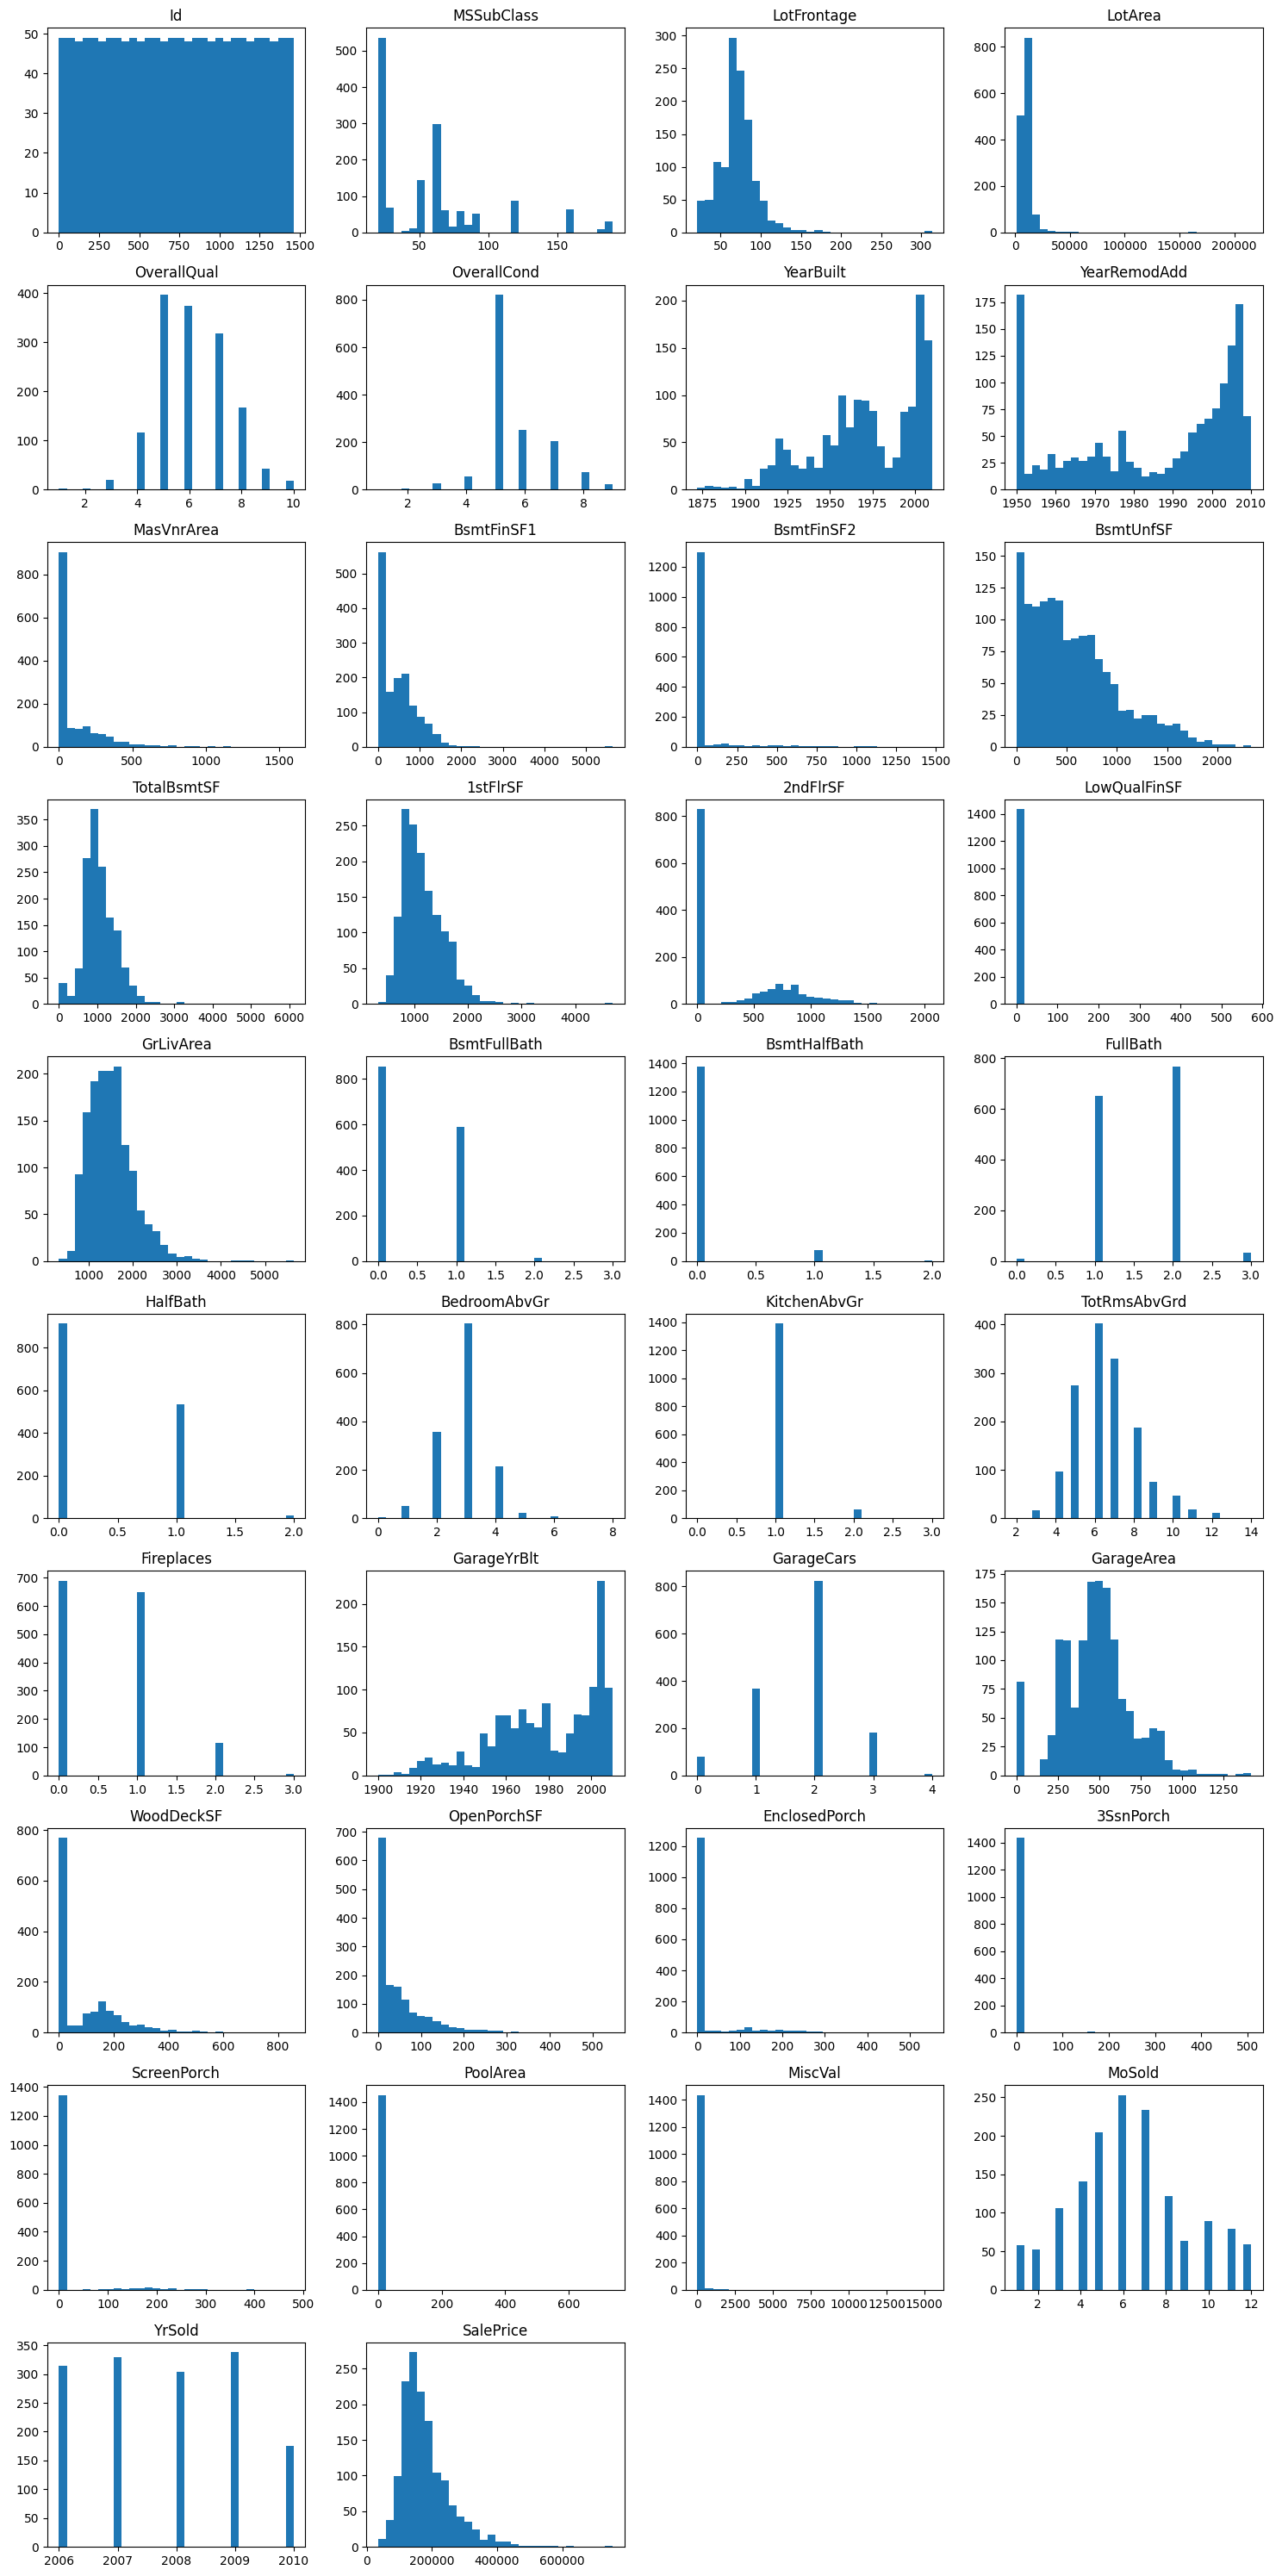

In [33]:
plt.figure(figsize=(15, 30))
for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 4, i)       
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [34]:
print(len(cat_cols))

43


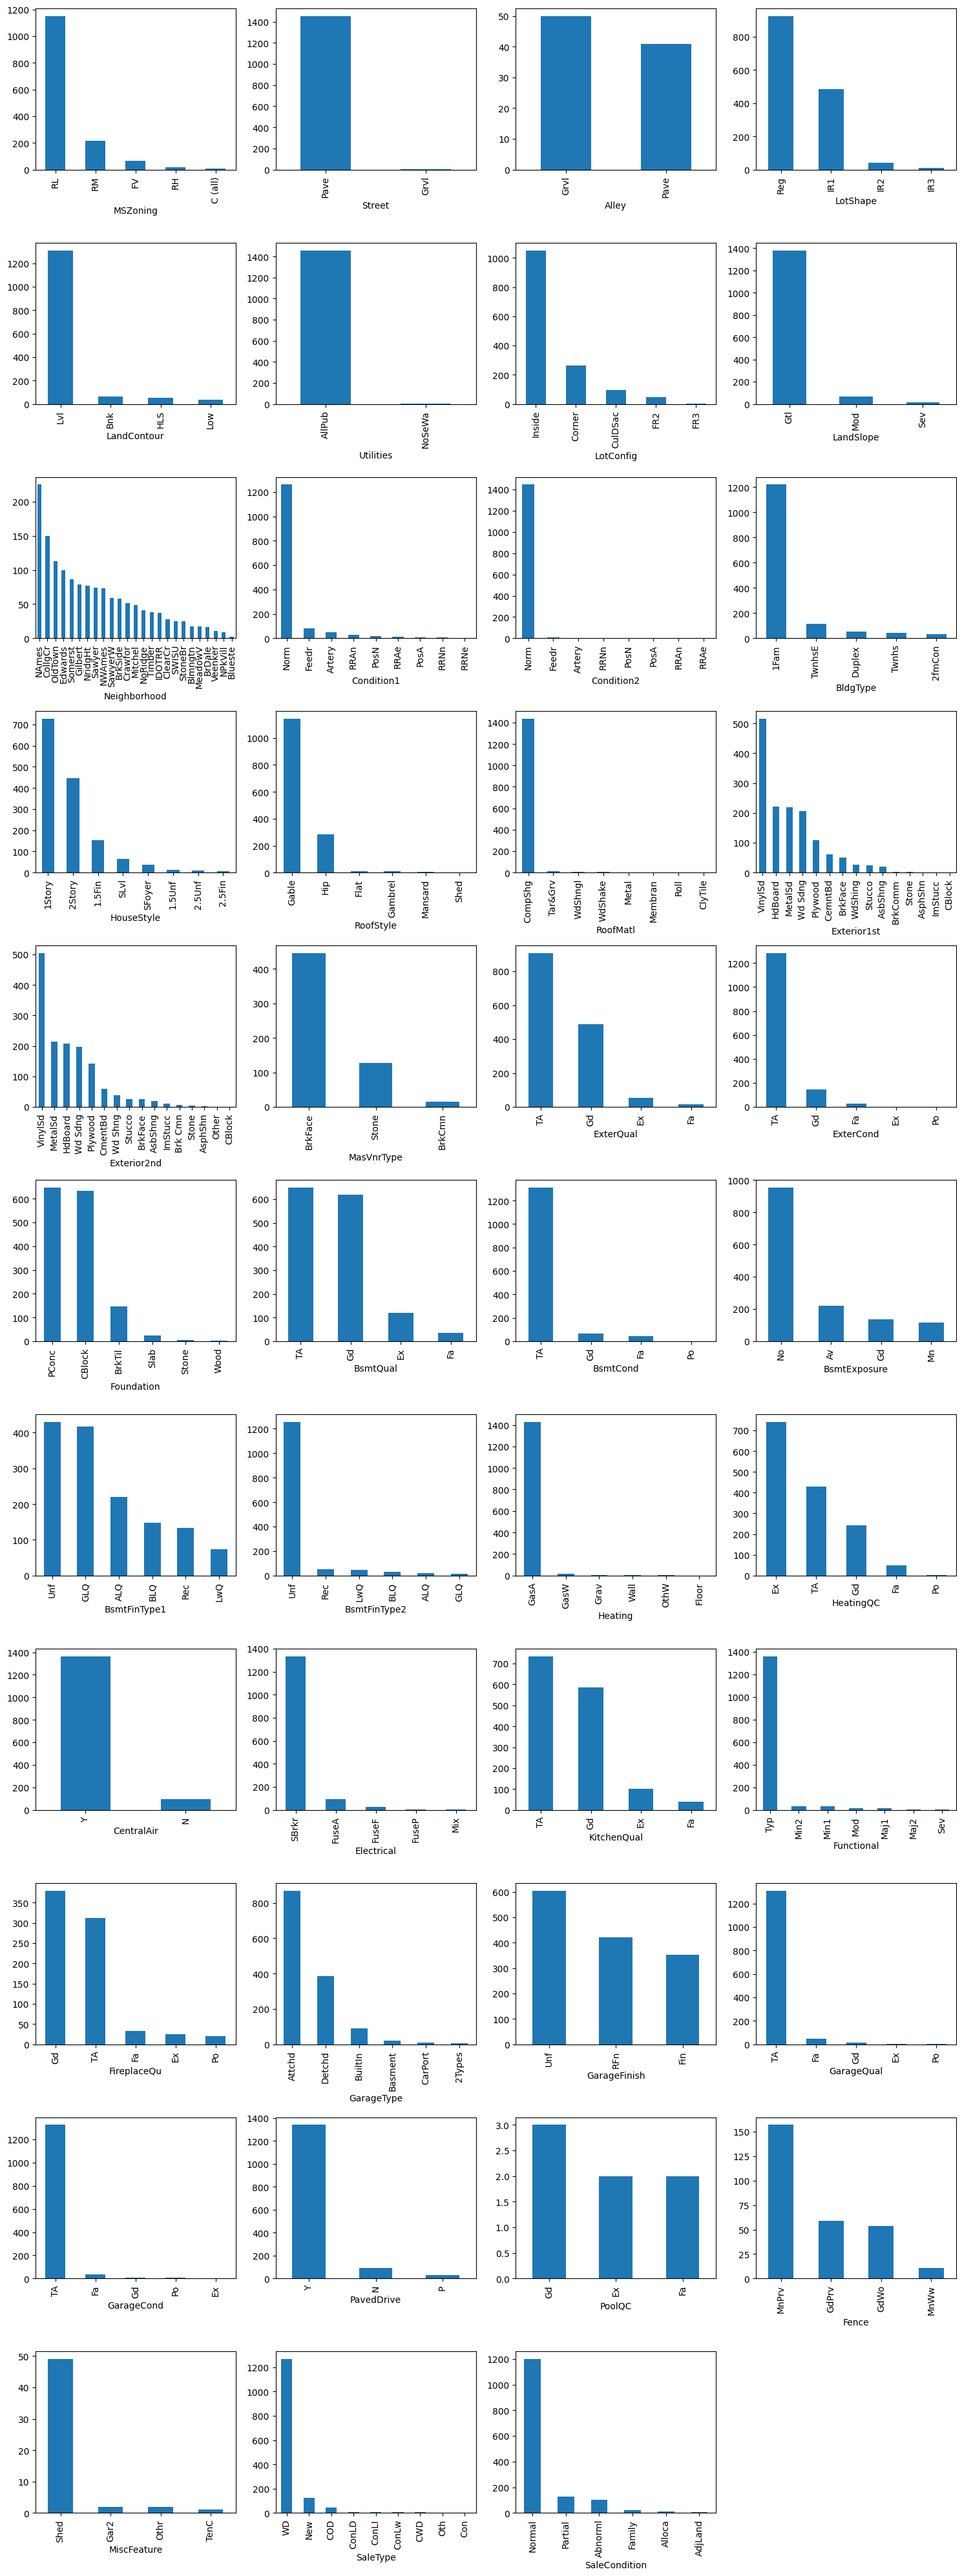

In [45]:
plt.figure(figsize=(15, 40))

for i,col in enumerate(cat_cols, 1):
    plt.subplot(11, 4, i)
    df[col].value_counts().plot(kind='bar')
    # plt.title(col)
plt.tight_layout()
plt.show()

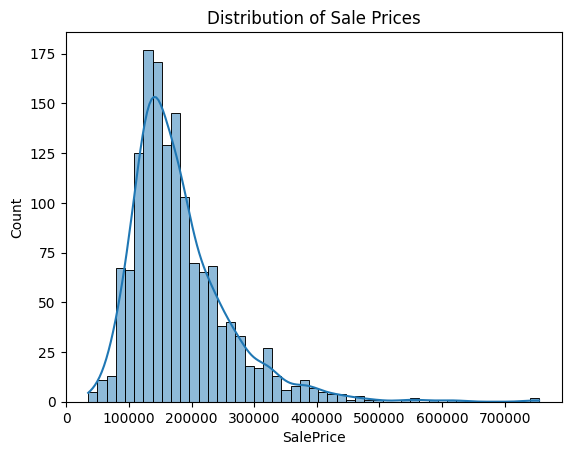

In [12]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.show()

In [14]:
print(df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
# Compute correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)

# Get correlation values with SalePrice, sorted descending
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

# Display the correlations
saleprice_corr


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

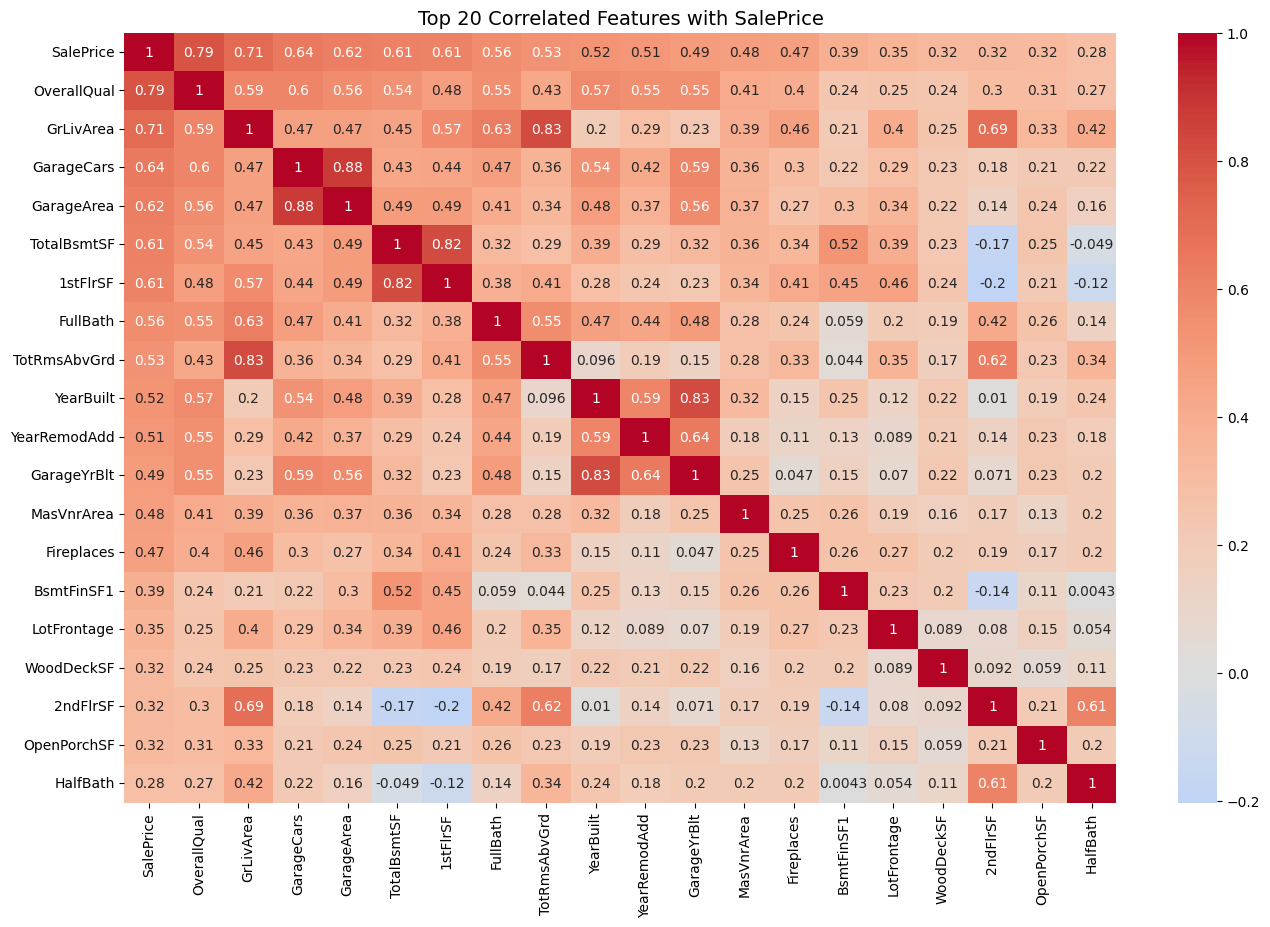

In [ ]:
# Get top 10 correlated numeric features with SalePrice
top_features = corr_matrix["SalePrice"].sort_values(ascending=False).head(20).index

plt.figure(figsize=(16,10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Top 20 Correlated Features with SalePrice", fontsize=14)
plt.show()

Key EDA Insights:
- Dataset: 1460 rows × 81 columns.

- Numeric columns: 38, Categorical columns: 43

- SalePrice is right-skewed → log transform recommended

- Top correlated features: OverallQual, GrLivArea, GarageCars, TotalBsmtSF

- High missingness in PoolQC, Alley, Fence, MiscFeature, FireplaceQu

- Some missing numeric fields: LotFrontage, MasVnrArea, GarageYrBlt

- Houses with better quality (OverallQual) and more living area tend to be more expensive